# Exploratory Transcriptomic Analysis of Inflammatory Patterns in Psoriasis-Associated Adipose Tissue


## Project Overview

This project explores a public RNA-seq dataset of cutaneous adipose tissue to examine how transcriptomic patterns differ across healthy control, lesional psoriasis, and non-lesional psoriasis samples. The analysis focuses on sample grouping, exploratory gene expression analysis, and visualisation of inflammatory patterns in psoriasis-associated adipose tissue.


### Research Question
How do transcriptomic patterns differ between healthy control, lesional psoriasis, and non-lesional psoriasis adipose tissue samples?


## 1. Import Required Libraries


In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Inspect the Data Files

In [40]:
print(os.listdir())

['.config', 'GSE287022_raw_counts_per_gene.csv', 'GSE287022_series_matrix.txt', 'sample_data']


In [41]:
counts = pd.read_csv("GSE287022_raw_counts_per_gene.csv")
counts.head()

,Unnamed: 0,sam114,sam148,sam143,sam150,sam113,sam117,sam151,sam145,sam115,...,sam81,sam77,sam6,sam56,sam88,sam48,sam73,sam87,sam84,sam55
0,ENSG00000223972,2,0,2,0,1,0,0,0,12,...,1,0,0,2,3,0,0,2,0,0
1,ENSG00000227232,405,705,562,450,545,504,812,466,440,...,698,833,555,795,824,941,321,779,744,1051
2,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000237613,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000268020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
counts.shape

(57905, 242)

In [43]:
counts.columns[:10]

Index(['Unnamed: 0', 'sam114', 'sam148', 'sam143', 'sam150', 'sam113',
       'sam117', 'sam151', 'sam145', 'sam115'],
      dtype='object')

In [44]:
counts.iloc[:5, :5]

,Unnamed: 0,sam114,sam148,sam143,sam150
0,ENSG00000223972,2,0,2,0
1,ENSG00000227232,405,705,562,450
2,ENSG00000243485,0,0,0,0
3,ENSG00000237613,0,0,0,0
4,ENSG00000268020,0,0,0,0


## 3. Extract and Clean Sample Metadata

In [45]:
with open("GSE287022_series_matrix.txt", "r") as f:
    lines = f.readlines()

sample_lines = [line.strip() for line in lines if line.startswith("!Sample")]

for line in sample_lines[:25]:
    print(line)

!Sample_title	"100F"	"101F"	"102F"	"103F"	"104F"	"105F"	"106F"	"107F"	"109F"	"11F"	"110F"	"111F"	"112F"	"113F"	"114F"	"115F"	"117F"	"119F"	"12F"	"143F"	"144F"	"145F"	"147F"	"148F"	"15F"	"150F"	"151F"	"152F"	"153F"	"154F"	"155F"	"156F"	"159F"	"16F"	"160F"	"161F"	"162F"	"163F"	"164F"	"165F"	"166F"	"167F"	"168F"	"169F"	"170F"	"171F"	"172F"	"173F"	"174F"	"175F"	"176F"	"177F"	"178F"	"179F"	"180F"	"181F"	"183F"	"184F"	"185F"	"186F"	"187F"	"188F"	"189F"	"19F"	"191F"	"193F"	"194F"	"195F"	"196F"	"197F"	"198F"	"199F"	"20F"	"200F"	"201F"	"202F"	"203F"	"204F"	"205F"	"206F"	"207F"	"208F"	"209F"	"21F"	"210F"	"211F"	"212F"	"213F"	"215F"	"216F"	"217F"	"218F"	"219F"	"22F"	"220F"	"221F"	"222F"	"223F"	"225F"	"226F"	"23F"	"231F"	"232F"	"233F"	"235F"	"236F"	"239F"	"24F"	"241F"	"242F"	"243F"	"25F"	"257F"	"258F"	"259F"	"260F"	"261F"	"262F"	"263F"	"264F"	"265F"	"266F"	"267F"	"268F"	"269F"	"27F"	"270F"	"271F"	"272F"	"273F"	"274F"	"275F"	"276F"	"277F"	"279F"	"28F"	"280F"	"281F"	"283F"	"285F"	"286F"	"287F"	"288F

In [47]:
sample_accession_line = [line for line in sample_lines if line.startswith("!Sample_geo_accession")][0]
sample_title_line = [line for line in sample_lines if line.startswith("!Sample_title")][0]
sample_source_line = [line for line in sample_lines if line.startswith("!Sample_source_name_ch1")][0]
sample_characteristics = [line for line in sample_lines if line.startswith("!Sample_characteristics_ch1")]

In [48]:
sample_ids = sample_accession_line.split("\t")[1:]
sample_titles = sample_title_line.split("\t")[1:]
sample_sources = sample_source_line.split("\t")[1:]

metadata = pd.DataFrame({
    "Sample_ID": sample_ids,
    "Title": sample_titles,
    "Source": sample_sources
})

for i, line in enumerate(sample_characteristics):
    values = line.split("\t")[1:]
    metadata[f"Characteristic_{i+1}"] = values

metadata.head()

,Sample_ID,Title,Source,Characteristic_1,Characteristic_2,Characteristic_3,Characteristic_4,Characteristic_5,Characteristic_6
0,"""GSM8736487""","""100F""","""Non-Lesional""","""tissue: Fat""","""condition: Psoriasis""","""timepoint: Week 12""","""tissue: Non-Lesional""","""treatment: Placebo""","""subjectid: 1005001"""
1,"""GSM8736488""","""101F""","""Lesional""","""tissue: Fat""","""condition: Psoriasis""","""timepoint: Baseline""","""tissue: Lesional""","""treatment: Secukinumab""","""subjectid: 1005002"""
2,"""GSM8736489""","""102F""","""Non-Lesional""","""tissue: Fat""","""condition: Psoriasis""","""timepoint: Baseline""","""tissue: Non-Lesional""","""treatment: Secukinumab""","""subjectid: 1005002"""
3,"""GSM8736490""","""103F""","""Lesional""","""tissue: Fat""","""condition: Psoriasis""","""timepoint: Week 12""","""tissue: Lesional""","""treatment: Secukinumab""","""subjectid: 1005002"""
4,"""GSM8736491""","""104F""","""Non-Lesional""","""tissue: Fat""","""condition: Psoriasis""","""timepoint: Week 12""","""tissue: Non-Lesional""","""treatment: Secukinumab""","""subjectid: 1005002"""


In [49]:
metadata_clean = metadata.copy()

str_cols = metadata_clean.select_dtypes(include="object").columns
metadata_clean[str_cols] = metadata_clean[str_cols].apply(lambda col: col.str.strip('"'))

metadata_clean["Condition"] = metadata_clean["Characteristic_2"].str.replace("condition: ", "", regex=False)
metadata_clean["Timepoint"] = metadata_clean["Characteristic_3"].str.replace("timepoint: ", "", regex=False)
metadata_clean["Tissue"] = metadata_clean["Characteristic_4"].str.replace("tissue: ", "", regex=False)
metadata_clean["Treatment"] = metadata_clean["Characteristic_5"].str.replace("treatment: ", "", regex=False)
metadata_clean["Subject_ID"] = metadata_clean["Characteristic_6"].str.replace("subjectid: ", "", regex=False)

metadata_clean[["Sample_ID", "Title", "Condition", "Timepoint", "Tissue", "Treatment", "Subject_ID"]].head(10)

,Sample_ID,Title,Condition,Timepoint,Tissue,Treatment,Subject_ID
0,GSM8736487,100F,Psoriasis,Week 12,Non-Lesional,Placebo,1005001
1,GSM8736488,101F,Psoriasis,Baseline,Lesional,Secukinumab,1005002
2,GSM8736489,102F,Psoriasis,Baseline,Non-Lesional,Secukinumab,1005002
3,GSM8736490,103F,Psoriasis,Week 12,Lesional,Secukinumab,1005002
4,GSM8736491,104F,Psoriasis,Week 12,Non-Lesional,Secukinumab,1005002
5,GSM8736492,105F,Psoriasis,Baseline,Lesional,Placebo,1005004
6,GSM8736493,106F,Psoriasis,Baseline,Non-Lesional,Placebo,1005004
7,GSM8736494,107F,Psoriasis,Week 12,Lesional,Placebo,1005004
8,GSM8736495,109F,Psoriasis,Baseline,Lesional,Placebo,1005005
9,GSM8736496,11F,Psoriasis,Baseline,Lesional,Secukinumab,1001004


Sample metadata were extracted from the GEO series matrix file and cleaned to identify biologically meaningful variables such as condition, tissue type, timepoint, and treatment.

## 4. Define Analysis Groups

In [50]:
metadata_filtered = metadata_clean[
    (
        (metadata_clean["Condition"] == "Healthy Vol.") &
        (metadata_clean["Tissue"] == "Normal")
    )
    |
    (
        (metadata_clean["Condition"] == "Psoriasis") &
        (metadata_clean["Timepoint"] == "Baseline") &
        (metadata_clean["Tissue"].isin(["Lesional", "Non-Lesional"]))
    )
].copy()

metadata_filtered[["Sample_ID", "Condition", "Timepoint", "Tissue", "Treatment"]].head(15)

,Sample_ID,Condition,Timepoint,Tissue,Treatment
1,GSM8736488,Psoriasis,Baseline,Lesional,Secukinumab
2,GSM8736489,Psoriasis,Baseline,Non-Lesional,Secukinumab
5,GSM8736492,Psoriasis,Baseline,Lesional,Placebo
6,GSM8736493,Psoriasis,Baseline,Non-Lesional,Placebo
8,GSM8736495,Psoriasis,Baseline,Lesional,Placebo
9,GSM8736496,Psoriasis,Baseline,Lesional,Secukinumab
10,GSM8736497,Psoriasis,Baseline,Non-Lesional,Placebo
13,GSM8736500,Psoriasis,Baseline,Lesional,Secukinumab
14,GSM8736501,Psoriasis,Baseline,Non-Lesional,Secukinumab
16,GSM8736503,Psoriasis,Baseline,Lesional,Secukinumab


In [51]:
def assign_group(row):
    if row["Condition"] == "Healthy Vol." and row["Tissue"] == "Normal":
        return "Healthy_Control"
    elif row["Condition"] == "Psoriasis" and row["Tissue"] == "Lesional" and row["Timepoint"] == "Baseline":
        return "Psoriasis_Lesional_Baseline"
    elif row["Condition"] == "Psoriasis" and row["Tissue"] == "Non-Lesional" and row["Timepoint"] == "Baseline":
        return "Psoriasis_NonLesional_Baseline"
    else:
        return "Other"

metadata_filtered["Group"] = metadata_filtered.apply(assign_group, axis=1)
metadata_filtered["Group"].value_counts()

,count
Group,
Psoriasis_Lesional_Baseline,69
Psoriasis_NonLesional_Baseline,57
Healthy_Control,13


For this exploratory analysis, samples were restricted to healthy controls and baseline psoriasis samples (lesional and non-lesional). This avoids confounding from treatment and follow-up timepoints and allows a cleaner comparison of transcriptomic patterns.

## 5. Prepare the Counts Matrix

In [52]:
counts.columns = [col.strip('"') if isinstance(col, str) else col for col in counts.columns]
counts.columns[:10]

Index(['Unnamed: 0', 'sam114', 'sam148', 'sam143', 'sam150', 'sam113',
       'sam117', 'sam151', 'sam145', 'sam115'],
      dtype='object')

In [53]:
matched_samples = list(set(metadata_filtered["Sample_ID"]).intersection(set(counts.columns)))
len(matched_samples)

0

In [54]:
matched_samples[:10]

[]

In [55]:
num_count_samples = len(counts.columns) - 1   # minus the first gene column
num_metadata_rows = len(metadata_clean)

print("Number of sample columns in counts:", num_count_samples)
print("Number of rows in metadata:", num_metadata_rows)

Number of sample columns in counts: 241
Number of rows in metadata: 241


In [56]:
sample_cols = list(counts.columns[1:])   # skip the first column, which is genes
metadata_clean["Count_Column"] = sample_cols

metadata_clean[["Sample_ID", "Title", "Count_Column", "Condition", "Timepoint", "Tissue"]].head(10)

,Sample_ID,Title,Count_Column,Condition,Timepoint,Tissue
0,GSM8736487,100F,sam114,Psoriasis,Week 12,Non-Lesional
1,GSM8736488,101F,sam148,Psoriasis,Baseline,Lesional
2,GSM8736489,102F,sam143,Psoriasis,Baseline,Non-Lesional
3,GSM8736490,103F,sam150,Psoriasis,Week 12,Lesional
4,GSM8736491,104F,sam113,Psoriasis,Week 12,Non-Lesional
5,GSM8736492,105F,sam117,Psoriasis,Baseline,Lesional
6,GSM8736493,106F,sam151,Psoriasis,Baseline,Non-Lesional
7,GSM8736494,107F,sam145,Psoriasis,Week 12,Lesional
8,GSM8736495,109F,sam115,Psoriasis,Baseline,Lesional
9,GSM8736496,11F,sam147,Psoriasis,Baseline,Lesional


In [58]:
metadata_filtered = metadata_clean[
    (
        (metadata_clean["Condition"] == "Healthy Vol.") &
        (metadata_clean["Tissue"] == "Normal")
    )
    |
    (
        (metadata_clean["Condition"] == "Psoriasis") &
        (metadata_clean["Timepoint"] == "Baseline") &
        (metadata_clean["Tissue"].isin(["Lesional", "Non-Lesional"]))
    )
].copy()

In [59]:
def assign_group(row):
    if row["Condition"] == "Healthy Vol." and row["Tissue"] == "Normal":
        return "Healthy_Control"
    elif row["Condition"] == "Psoriasis" and row["Tissue"] == "Lesional" and row["Timepoint"] == "Baseline":
        return "Psoriasis_Lesional_Baseline"
    elif row["Condition"] == "Psoriasis" and row["Tissue"] == "Non-Lesional" and row["Timepoint"] == "Baseline":
        return "Psoriasis_NonLesional_Baseline"
    else:
        return "Other"

metadata_filtered["Group"] = metadata_filtered.apply(assign_group, axis=1)
metadata_filtered["Group"].value_counts()

,count
Group,
Psoriasis_Lesional_Baseline,69
Psoriasis_NonLesional_Baseline,57
Healthy_Control,13


In [60]:
matched_samples = metadata_filtered["Count_Column"].tolist()
len(matched_samples), matched_samples[:10]

(139,
 ['sam148',
  'sam143',
  'sam117',
  'sam151',
  'sam115',
  'sam147',
  'sam144',
  'sam167',
  'sam105',
  'sam180'])

In [61]:
gene_col = counts.columns[0]
counts_subset = counts[[gene_col] + matched_samples].copy()
counts_subset.head()

,Unnamed: 0,sam148,sam143,sam117,sam151,sam115,sam147,sam144,sam167,sam105,...,sam47,sam78,sam57,sam5,sam91,sam6,sam56,sam73,sam87,sam84
0,ENSG00000223972,0,2,0,0,12,1,0,0,0,...,0,0,0,1,1,0,2,0,2,0
1,ENSG00000227232,705,562,504,812,440,505,525,728,370,...,1065,667,649,748,355,555,795,321,779,744
2,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000237613,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000268020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 6. Exploratory Transcriptomic Analysis

This section focuses on exploratory analysis of the transcriptomic data. To make the count data easier to interpret, the selected expression matrix is prepared, transformed, and used to identify genes with the greatest variability across the sample groups.

In [62]:
counts_subset.head()

,Unnamed: 0,sam148,sam143,sam117,sam151,sam115,sam147,sam144,sam167,sam105,...,sam47,sam78,sam57,sam5,sam91,sam6,sam56,sam73,sam87,sam84
0,ENSG00000223972,0,2,0,0,12,1,0,0,0,...,0,0,0,1,1,0,2,0,2,0
1,ENSG00000227232,705,562,504,812,440,505,525,728,370,...,1065,667,649,748,355,555,795,321,779,744
2,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000237613,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000268020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
gene_col = counts_subset.columns[0]
print("Gene column name:", gene_col)
print(counts_subset[gene_col].head())

Gene column name: Unnamed: 0
0    ENSG00000223972
1    ENSG00000227232
2    ENSG00000243485
3    ENSG00000237613
4    ENSG00000268020
Name: Unnamed: 0, dtype: object


In [64]:
expression = counts_subset.set_index(gene_col)
expression.head()

,sam148,sam143,sam117,sam151,sam115,sam147,sam144,sam167,sam105,sam180,...,sam47,sam78,sam57,sam5,sam91,sam6,sam56,sam73,sam87,sam84
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,2,0,0,12,1,0,0,0,0,...,0,0,0,1,1,0,2,0,2,0
ENSG00000227232,705,562,504,812,440,505,525,728,370,416,...,1065,667,649,748,355,555,795,321,779,744
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
expression.shape

(57905, 139)

In [66]:
expression = expression.apply(pd.to_numeric, errors="coerce")
expression.dtypes.head()

,0
sam148,int64
sam143,int64
sam117,int64
sam151,int64
sam115,int64


In [67]:
expression.isnull().sum().sum()

np.int64(0)

In [68]:
expression_log = np.log1p(expression)
expression_log.head()

,sam148,sam143,sam117,sam151,sam115,sam147,sam144,sam167,sam105,sam180,...,sam47,sam78,sam57,sam5,sam91,sam6,sam56,sam73,sam87,sam84
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0.000000,1.098612,0.000000,0.000000,2.564949,0.693147,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.693147,0.693147,0.000000,1.098612,0.000000,1.098612,0.000000
ENSG00000227232,6.559615,6.333280,6.224558,6.700731,6.089045,6.226537,6.265301,6.591674,5.916202,6.033086,...,6.971669,6.504288,6.476972,6.618739,5.874931,6.320768,6.679599,5.774552,6.659294,6.613384
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000268020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The raw counts were log-transformed using log1p to reduce skewness and make expression patterns easier to compare visually across samples.

In [69]:
metadata_filtered["Group"].value_counts()

,count
Group,
Psoriasis_Lesional_Baseline,69
Psoriasis_NonLesional_Baseline,57
Healthy_Control,13


In [70]:
group_order = [
    "Healthy_Control",
    "Psoriasis_NonLesional_Baseline",
    "Psoriasis_Lesional_Baseline"
]

metadata_filtered["Group"] = pd.Categorical(metadata_filtered["Group"], categories=group_order, ordered=True)
metadata_filtered = metadata_filtered.sort_values("Group")
metadata_filtered[["Sample_ID", "Count_Column", "Group"]].head(15)

,Sample_ID,Count_Column,Group
193,GSM8736680,sam270,Healthy_Control
194,GSM8736681,sam461,Healthy_Control
196,GSM8736683,sam119,Healthy_Control
192,GSM8736679,sam196,Healthy_Control
191,GSM8736678,sam31,Healthy_Control
197,GSM8736684,sam70,Healthy_Control
190,GSM8736677,sam307,Healthy_Control
189,GSM8736676,sam293,Healthy_Control
188,GSM8736675,sam200,Healthy_Control
195,GSM8736682,sam34,Healthy_Control


In [71]:
ordered_samples = metadata_filtered["Count_Column"].tolist()
ordered_samples[:10]

['sam270',
 'sam461',
 'sam119',
 'sam196',
 'sam31',
 'sam70',
 'sam307',
 'sam293',
 'sam200',
 'sam34']

In [72]:
expression_log = expression_log[ordered_samples]
expression_log.head()

,sam270,sam461,sam119,sam196,sam31,sam70,sam307,sam293,sam200,sam34,...,sam290,sam269,sam29,sam27,sam285,sam268,sam233,sam223,sam179,sam298
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0.000000,0.000000,0.000000,0.693147,0.000000,0.693147,0.000000,0.000000,0.000000,1.098612,...,2.079442,0.000000,0.000000,0.000000,0.693147,0.000000,2.302585,0.00000,0.693147,0.00000
ENSG00000227232,6.167516,5.398163,5.472271,6.752270,6.066108,6.124683,5.697093,5.560682,6.086775,6.934397,...,6.204558,6.517671,6.291569,5.894403,6.646391,6.673298,5.700444,6.77308,6.190315,6.34388
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.098612,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
ENSG00000237613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
ENSG00000268020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000


In [73]:
gene_variance = expression_log.var(axis=1)
top_variable_genes = gene_variance.sort_values(ascending=False).head(30).index
top_variable_genes

Index(['ENSG00000161634', 'ENSG00000172551', 'ENSG00000110484',
       'ENSG00000171346', 'ENSG00000159763', 'ENSG00000124935',
       'ENSG00000131686', 'ENSG00000129824', 'ENSG00000185479',
       'ENSG00000007216', 'ENSG00000161798', 'ENSG00000205420',
       'ENSG00000105929', 'ENSG00000134240', 'ENSG00000012817',
       'ENSG00000128422', 'ENSG00000178372', 'ENSG00000134762',
       'ENSG00000067048', 'ENSG00000184012', 'ENSG00000229807',
       'ENSG00000121742', 'ENSG00000214128', 'ENSG00000206075',
       'ENSG00000141750', 'ENSG00000131746', 'ENSG00000230937',
       'ENSG00000134757', 'ENSG00000043039', 'ENSG00000168269'],
      dtype='object', name='Unnamed: 0')

In [74]:
top_expression = expression_log.loc[top_variable_genes]
top_expression.head()

,sam270,sam461,sam119,sam196,sam31,sam70,sam307,sam293,sam200,sam34,...,sam290,sam269,sam29,sam27,sam285,sam268,sam233,sam223,sam179,sam298
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000161634,12.457788,3.258097,4.094345,1.791759,10.020959,3.091042,3.465736,2.397895,0.000000,12.126326,...,11.102156,13.559381,9.386057,5.433722,2.772589,9.090881,4.465908,13.081558,7.044905,4.812184
ENSG00000172551,10.375895,1.098612,2.564949,0.000000,8.525360,1.945910,3.135494,0.693147,0.693147,10.517429,...,8.710455,11.349912,9.043459,4.430817,1.098612,7.189168,1.945910,11.364739,6.033086,1.945910
ENSG00000110484,10.838364,1.098612,3.332205,0.000000,8.941415,0.693147,2.397895,1.098612,0.000000,10.774969,...,9.536979,11.996197,8.208764,3.806662,1.945910,7.928406,1.945910,10.379629,5.323010,2.772589
ENSG00000171346,10.763631,1.098612,2.484907,0.000000,8.693497,1.098612,3.496508,2.079442,0.000000,10.288274,...,9.569133,11.465456,8.559678,3.761200,0.693147,8.682369,0.693147,10.782243,4.859812,0.693147
ENSG00000159763,10.474806,1.609438,1.098612,0.693147,6.843750,1.609438,0.693147,0.000000,1.098612,8.482188,...,8.076205,11.379291,7.070724,3.178054,0.000000,5.968708,2.197225,10.694306,4.418841,1.098612


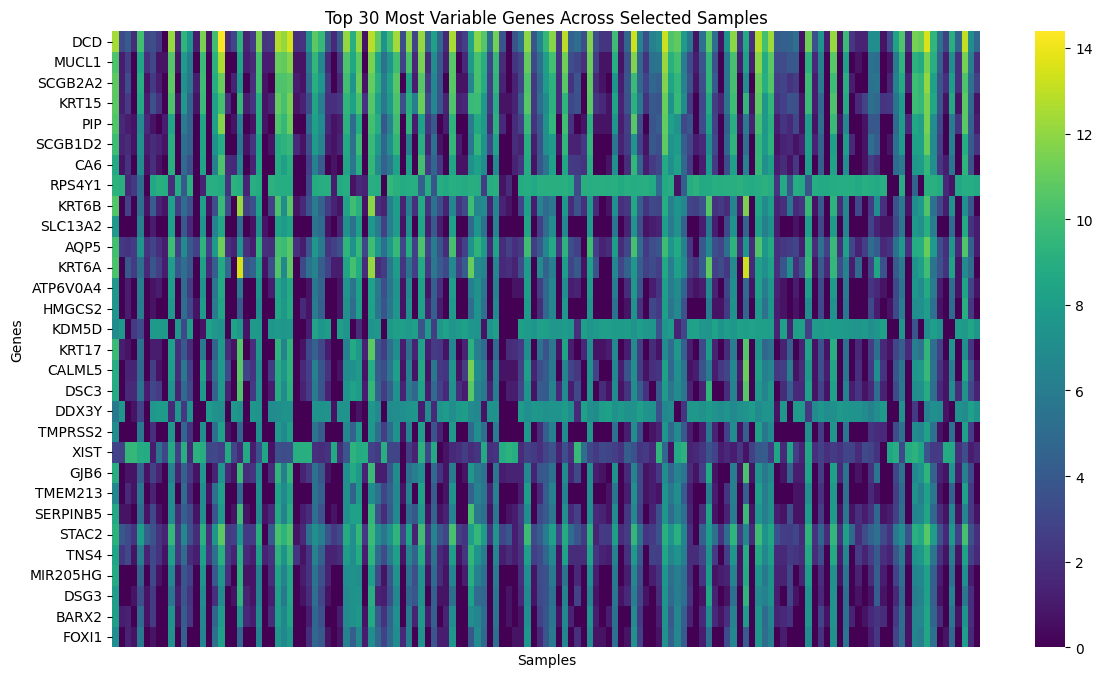

In [101]:
top_expression_named = top_expression.copy()
top_expression_named.index = [
    id_to_symbol.get(gene_id, gene_id) for gene_id in top_expression_named.index
]

plt.figure(figsize=(14,8))
sns.heatmap(top_expression_named, cmap="viridis", yticklabels=True, xticklabels=False)
plt.title("Top 30 Most Variable Genes Across Selected Samples")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.show()

The heatmap of the most variable genes provides an initial view of transcriptomic heterogeneity across the selected sample groups. Differences in expression patterns across healthy control, non-lesional psoriasis, and lesional psoriasis samples may reflect biologically meaningful inflammatory variation.

## 7. Visualisation

This section uses dimensionality reduction and grouped visualisation to explore whether healthy control, non-lesional psoriasis, and lesional psoriasis samples show distinct transcriptomic patterns.

In [77]:
metadata_plot = metadata_filtered.set_index("Count_Column").loc[ordered_samples].reset_index()
metadata_plot[["Count_Column", "Group"]].head()

,Count_Column,Group
0,sam270,Healthy_Control
1,sam461,Healthy_Control
2,sam119,Healthy_Control
3,sam196,Healthy_Control
4,sam31,Healthy_Control


In [78]:
pca_input = top_expression.T
pca_input.shape

(139, 30)

In [79]:
from sklearn.decomposition import PCA

In [80]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(pca_input)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=pca_input.index).reset_index()
pca_df = pca_df.rename(columns={"index": "Count_Column"})
pca_df = pca_df.merge(metadata_plot[["Count_Column", "Group"]], on="Count_Column")

pca_df.head()

,Count_Column,PC1,PC2,Group
0,sam270,26.477312,1.795991,Healthy_Control
1,sam461,-15.515247,4.257336,Healthy_Control
2,sam119,-11.463644,-10.648646,Healthy_Control
3,sam196,-17.109124,-8.635212,Healthy_Control
4,sam31,12.177302,-6.101979,Healthy_Control


In [81]:
pca.explained_variance_ratio_

array([0.81991498, 0.1181319 ])

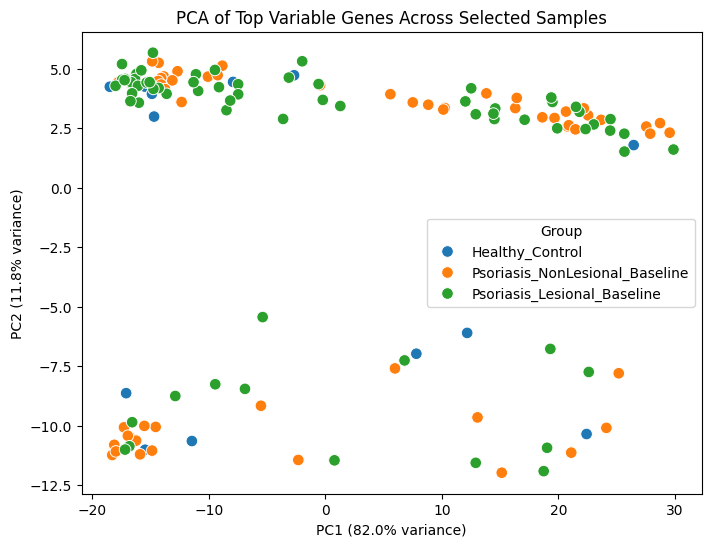

In [82]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Group", s=70)
plt.title("PCA of Top Variable Genes Across Selected Samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

The PCA plot provides a low-dimensional view of transcriptomic variation across the selected samples. PC1 explained 82.0% of the variance and PC2 explained 11.8%, suggesting that a large proportion of overall variation was captured in the first two components. While the three groups showed partial overlap, the distribution of samples indicates meaningful transcriptomic heterogeneity across healthy control, non-lesional psoriasis, and lesional psoriasis adipose tissue.

In [86]:
counts = counts.rename(columns={counts.columns[0]: "Ensembl_ID"})

In [87]:
metadata_filtered["Group_Short"] = metadata_filtered["Group"].replace({
    "Healthy_Control": "Healthy",
    "Psoriasis_NonLesional_Baseline": "NonLesional",
    "Psoriasis_Lesional_Baseline": "Lesional"
})

metadata_filtered[["Group", "Group_Short"]].drop_duplicates()

/tmp/ipykernel_31483/746662865.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  metadata_filtered["Group_Short"] = metadata_filtered["Group"].replace({


,Group,Group_Short
193,Healthy_Control,Healthy
86,Psoriasis_NonLesional_Baseline,NonLesional
172,Psoriasis_Lesional_Baseline,Lesional


In [88]:
group_map_short = metadata_filtered.set_index("Count_Column")["Group_Short"]

group_mean_expression_short = (
    expression_log[ordered_samples]
    .T
    .join(group_map_short.rename("Group"))
    .groupby("Group")
    .mean()
    .T
)

group_mean_expression_short.head()

/tmp/ipykernel_31483/1650254019.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Group")


Group,Healthy,NonLesional,Lesional
ENSG00000223972,0.297785,0.496039,0.625038
ENSG00000227232,6.212525,6.425583,6.327203
ENSG00000243485,0.084509,0.024321,0.025968
ENSG00000237613,0.000000,0.000000,0.000000
ENSG00000268020,0.000000,0.000000,0.000000


In [103]:
top_group_expression_short = group_mean_expression_short.loc[top_variable_genes]
top_group_expression_short.head()

Group,Healthy,NonLesional,Lesional
Unnamed: 0,,,
ENSG00000161634,5.450826,6.937991,6.525794
ENSG00000172551,4.154303,5.504806,5.155886
ENSG00000110484,4.013884,5.243053,4.914601
ENSG00000171346,4.080518,5.509639,4.879692
ENSG00000159763,3.321112,4.559879,4.175070


In [89]:
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00


In [91]:
import mygene

mg = mygene.MyGeneInfo()

In [92]:
top_gene_ids = list(top_variable_genes)
top_gene_ids[:10]

['ENSG00000161634',
 'ENSG00000172551',
 'ENSG00000110484',
 'ENSG00000171346',
 'ENSG00000159763',
 'ENSG00000124935',
 'ENSG00000131686',
 'ENSG00000129824',
 'ENSG00000185479',
 'ENSG00000007216']

In [93]:
gene_info = mg.querymany(
    top_gene_ids,
    scopes="ensembl.gene",
    fields="symbol,name",
    species="human"
)

gene_info[:5]

INFO:biothings.client:querying 1-30 ...
INFO:biothings.client:Finished.


[{'query': 'ENSG00000161634',
  '_id': '117159',
  '_score': 32.912014,
  'name': 'dermcidin',
  'symbol': 'DCD'},
 {'query': 'ENSG00000172551',
  '_id': '118430',
  '_score': 32.912014,
  'name': 'mucin like 1',
  'symbol': 'MUCL1'},
 {'query': 'ENSG00000110484',
  '_id': '4250',
  '_score': 32.912014,
  'name': 'secretoglobin family 2A member 2',
  'symbol': 'SCGB2A2'},
 {'query': 'ENSG00000171346',
  '_id': '3866',
  '_score': 32.912014,
  'name': 'keratin 15',
  'symbol': 'KRT15'},
 {'query': 'ENSG00000159763',
  '_id': '5304',
  '_score': 32.91158,
  'name': 'prolactin induced protein',
  'symbol': 'PIP'}]

In [94]:
mapping_df = pd.DataFrame(gene_info)[["query", "symbol", "name"]]
mapping_df

,query,symbol,name
0,ENSG00000161634,DCD,dermcidin
1,ENSG00000172551,MUCL1,mucin like 1
2,ENSG00000110484,SCGB2A2,secretoglobin family 2A member 2
3,ENSG00000171346,KRT15,keratin 15
4,ENSG00000159763,PIP,prolactin induced protein
5,ENSG00000124935,SCGB1D2,secretoglobin family 1D member 2
6,ENSG00000131686,CA6,carbonic anhydrase 6
7,ENSG00000129824,RPS4Y1,ribosomal protein S4 Y-linked 1
8,ENSG00000185479,KRT6B,keratin 6B
9,ENSG00000007216,SLC13A2,solute carrier family 13 member 2


In [95]:
id_to_symbol = dict(zip(mapping_df["query"], mapping_df["symbol"]))
id_to_symbol

{'ENSG00000161634': 'DCD',
 'ENSG00000172551': 'MUCL1',
 'ENSG00000110484': 'SCGB2A2',
 'ENSG00000171346': 'KRT15',
 'ENSG00000159763': 'PIP',
 'ENSG00000124935': 'SCGB1D2',
 'ENSG00000131686': 'CA6',
 'ENSG00000129824': 'RPS4Y1',
 'ENSG00000185479': 'KRT6B',
 'ENSG00000007216': 'SLC13A2',
 'ENSG00000161798': 'AQP5',
 'ENSG00000205420': 'KRT6A',
 'ENSG00000105929': 'ATP6V0A4',
 'ENSG00000134240': 'HMGCS2',
 'ENSG00000012817': 'KDM5D',
 'ENSG00000128422': 'KRT17',
 'ENSG00000178372': 'CALML5',
 'ENSG00000134762': 'DSC3',
 'ENSG00000067048': 'DDX3Y',
 'ENSG00000184012': 'TMPRSS2',
 'ENSG00000229807': 'XIST',
 'ENSG00000121742': 'GJB6',
 'ENSG00000214128': 'TMEM213',
 'ENSG00000206075': 'SERPINB5',
 'ENSG00000141750': 'STAC2',
 'ENSG00000131746': 'TNS4',
 'ENSG00000230937': 'MIR205HG',
 'ENSG00000134757': 'DSG3',
 'ENSG00000043039': 'BARX2',
 'ENSG00000168269': 'FOXI1'}

In [96]:
top_group_expression_short = group_mean_expression_short.loc[top_variable_genes].copy()

top_group_expression_named = top_group_expression_short.copy()
top_group_expression_named.index = [
    id_to_symbol.get(gene_id, gene_id) for gene_id in top_group_expression_named.index
]

top_group_expression_named.head()

Group,Healthy,NonLesional,Lesional
DCD,5.450826,6.937991,6.525794
MUCL1,4.154303,5.504806,5.155886
SCGB2A2,4.013884,5.243053,4.914601
KRT15,4.080518,5.509639,4.879692
PIP,3.321112,4.559879,4.175070


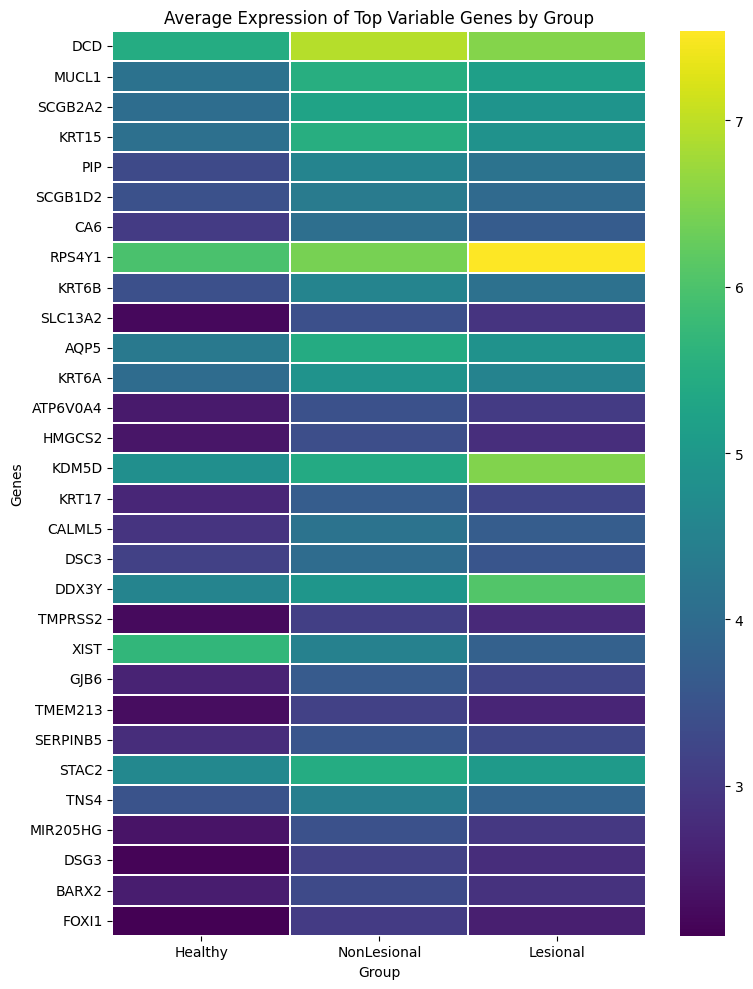

In [105]:
plt.figure(figsize=(8,10))
sns.heatmap(top_group_expression_named, cmap="viridis", linewidths=0.2)
plt.title("Average Expression of Top Variable Genes by Group")
plt.xlabel("Group")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

The group-average heatmap provides a clearer summary of transcriptomic differences across Healthy, NonLesional, and Lesional adipose tissue samples. Several highly variable genes showed distinct average expression patterns across the three groups. While some genes appeared elevated in both psoriasis-associated groups relative to healthy controls, others differed between non-lesional and lesional tissue, suggesting biologically meaningful heterogeneity within psoriasis-associated adipose tissue.

In [102]:
mapping_df[mapping_df["symbol"].isna()]

,query,symbol,name


## 8. Key Findings

## Key Findings

- The selected adipose tissue samples showed clear transcriptomic
variability across healthy control, non-lesional psoriasis, and lesional psoriasis groups.
- The PCA captured most of the overall variation within the first two components, suggesting that major expression differences were reflected in the reduced-dimensional view.
- The grouped heatmap showed that several highly variable genes differed in their average expression across the three groups, pointing towards meaningful biological differences in the tissue states.
- Non-lesional and lesional psoriasis-associated adipose tissue did not appear transcriptomically identical, which suggests that even tissue not visibly lesional may still carry distinct molecular changes.
- Overall, this project helped me understand how public RNA-seq data can be organised, filtered, transformed, and visualised to explore transcriptomic patterns in a clinically relevant disease context.